# Analyse Exploratoire - Togo
## Optimisation de la Chaîne de Valeur Agricole et Résilience aux Chocs

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from src.data_loader import load_all_togo_data, get_wa_comparison
from src.visualization import plot_time_series, plot_dual_axis, plot_interactive_time_series
from src.models import SupplyChainRiskModel

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Chargement des données

In [2]:
data = load_all_togo_data()
inflation = data['inflation']
gdp = data['gdp']

print(f"Inflation: {len(inflation)} observations ({inflation['Year'].min()}-{inflation['Year'].max()})")
print(f"PIB: {len(gdp)} observations ({gdp['Year'].min()}-{gdp['Year'].max()})")

Inflation: 58 observations (1967.0-2024.0)
PIB: 65 observations (1960.0-2024.0)


In [3]:
inflation.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
2094,Togo,TGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,1967.0,-2.318841
2360,Togo,TGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,1968.0,0.296736
2626,Togo,TGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,1969.0,6.015779
2892,Togo,TGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,1970.0,4.480620
3158,Togo,TGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,1971.0,6.492061


In [4]:
gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
232,Togo,TGO,PIB ($ US courants),NY.GDP.MKTP.CD,1960.0,1.710571e+08
498,Togo,TGO,PIB ($ US courants),NY.GDP.MKTP.CD,1961.0,1.784971e+08
764,Togo,TGO,PIB ($ US courants),NY.GDP.MKTP.CD,1962.0,1.867458e+08
1030,Togo,TGO,PIB ($ US courants),NY.GDP.MKTP.CD,1963.0,2.023059e+08
1296,Togo,TGO,PIB ($ US courants),NY.GDP.MKTP.CD,1964.0,2.345722e+08


## 2. Statistiques descriptives

In [5]:
print("=== Inflation Togo ===")
display(inflation['Value'].describe())
print("\n=== PIB Togo ===")
display(gdp['Value'].describe())

=== Inflation Togo ===


count    58.000000
mean      4.962137
std       7.189885
min      -3.526629
25%       0.500743
50%       2.723812
75%       7.350171
max      39.162767
Name: Value, dtype: float64


=== PIB Togo ===


count    6.500000e+01
mean     2.818952e+09
std      2.651956e+09
min      1.710571e+08
25%      8.746816e+08
50%      1.947208e+09
75%      4.578847e+09
max      1.065118e+10
Name: Value, dtype: float64

## 3. Évolution temporelle

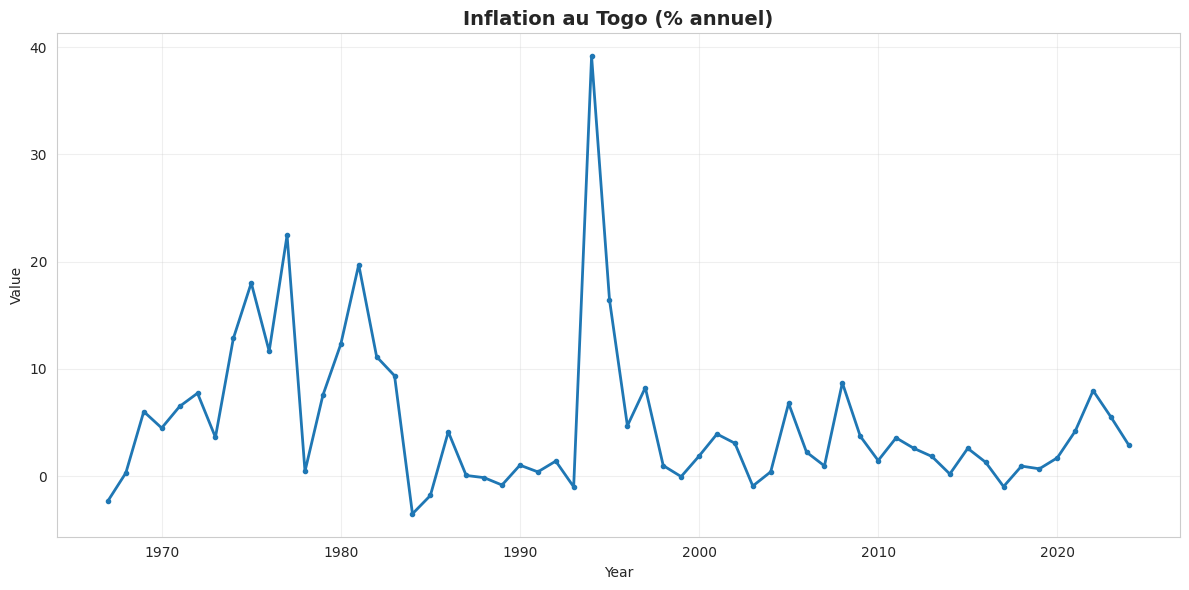

In [6]:
plot_time_series(inflation, title='Inflation au Togo (% annuel)')
plt.show()

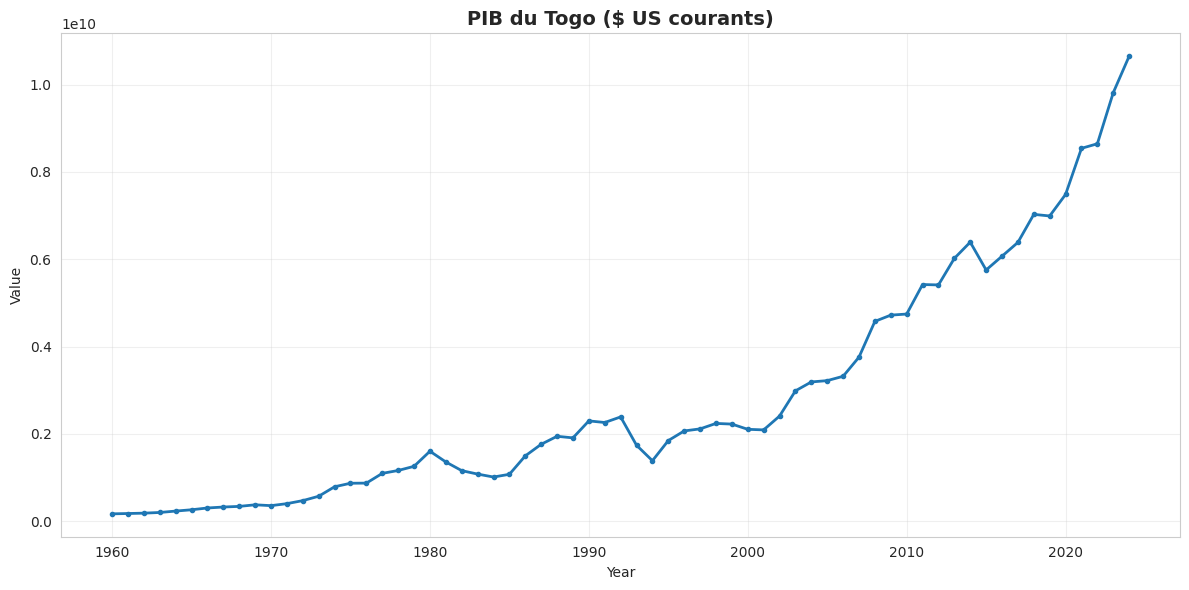

In [7]:
plot_time_series(gdp, title='PIB du Togo ($ US courants)')
plt.show()

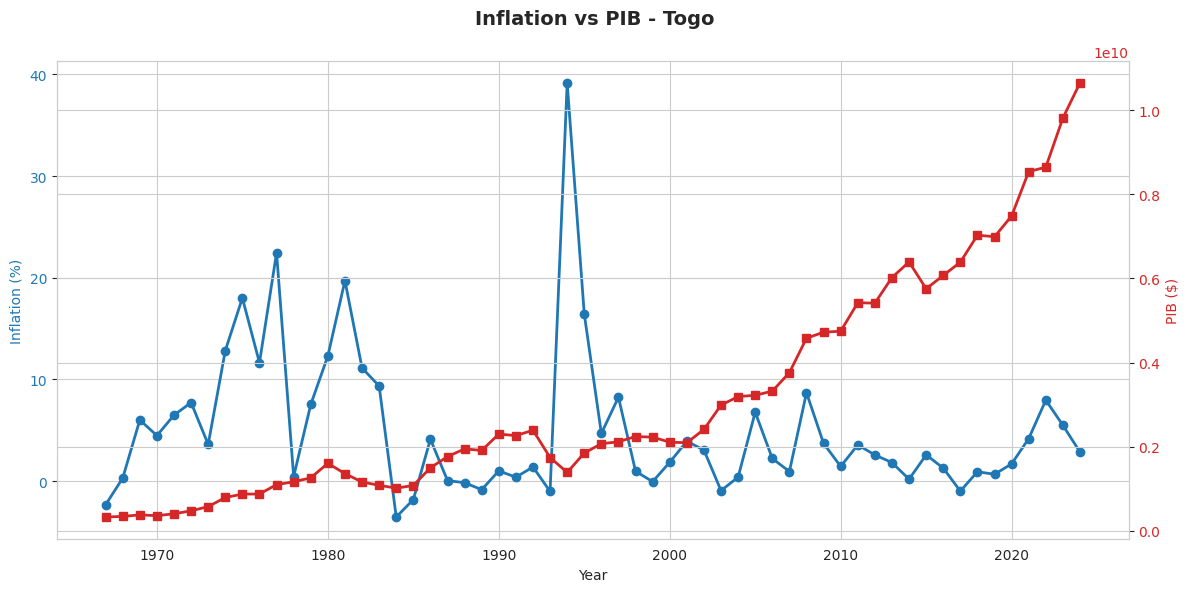

In [8]:
merged = inflation.merge(gdp, on='Year', suffixes=('_inflation', '_gdp'))
plot_dual_axis(merged, 'Year', 'Value_inflation', 'Value_gdp',
               label1='Inflation (%)', label2='PIB ($)',
               title='Inflation vs PIB - Togo')
plt.show()

## 4. Comparaison ouest-africaine

In [9]:
wa_inflation = get_wa_comparison('inflation')
recent = wa_inflation[wa_inflation['Year'] >= 2010]

fig = px.line(recent, x='Year', y='Value', color='Country Name',
              title='Inflation en Afrique de l\'Ouest (2010+)',
              markers=True, template='plotly_white')
fig.update_layout(hovermode='x unified')
fig.show()

## 5. Analyse des risques (Supply Chain)

In [10]:
merged = inflation.rename(columns={'Value': 'inflation'})
gdp_renamed = gdp.rename(columns={'Value': 'gdp'})
merged = merged.merge(gdp_renamed[['Year', 'gdp']], on='Year')

risk_model = SupplyChainRiskModel()
risk_df = risk_model.compute_risk_score(merged)

fig = px.line(risk_df, x='Year', y='risk_score',
              title='Indice de Risque d\'Approvisionnement - Togo',
              markers=True, template='plotly_white')
fig.add_hline(y=0.5, line_dash='dash', line_color='orange',
              annotation_text='Seuil Élevé')
fig.add_hline(y=0.75, line_dash='dash', line_color='red',
              annotation_text='Seuil Critique')
fig.show()

In [11]:
risk_counts = risk_df['risk_level'].value_counts()
fig = px.pie(values=risk_counts.values, names=risk_counts.index,
             title='Répartition des Niveaux de Risque',
             color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

## 6. Périodes de crise identifiées

In [12]:
crisis = risk_df[risk_df['risk_level'].isin(['Élevé', 'Critique'])]
print("Périodes de risque élevé/critique :")
display(crisis[['Year', 'inflation', 'gdp', 'risk_score', 'risk_level']])

Périodes de risque élevé/critique :


,Year,inflation,gdp,risk_score,risk_level
10,1977.0,22.457013,1.097894e+09,0.513138,Élevé
27,1994.0,39.162767,1.387662e+09,1.000000,Critique
28,1995.0,16.433503,1.849110e+09,0.820521,Critique


## 7. Corrélations

In [13]:
from src.visualization import plot_correlation_heatmap
merged_corr = merged.drop(columns=['Country Name_x', 'Country Code_x',
                                    'Indicator Name_x', 'Indicator Code_x'])
merged_corr = merged_corr.select_dtypes(include=[np.number]).dropna()
plot_correlation_heatmap(merged_corr, title='Corrélations - Inflation & PIB Togo')
plt.show()

KeyError: "['Country Name_x', 'Country Code_x', 'Indicator Name_x', 'Indicator Code_x'] not found in axis"

## 8. Conclusion et prochaines étapes

### Observations clés :
- L'inflation au Togo montre une volatilité significative
- Le PIB a connu une croissance soutenue sur la dernière décennie
- Plusieurs épisodes de risque critique identifiés (chocs macroéconomiques)

### Prochaines étapes :
1. Intégrer les données FAO (rendements soja, coton)
2. Collecter les données climatiques (précipitations, température)
3. Développer le modèle prédictif de rendement
4. Construire le tableau de bord interactif